## 6a: Binarization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

from numba import cuda

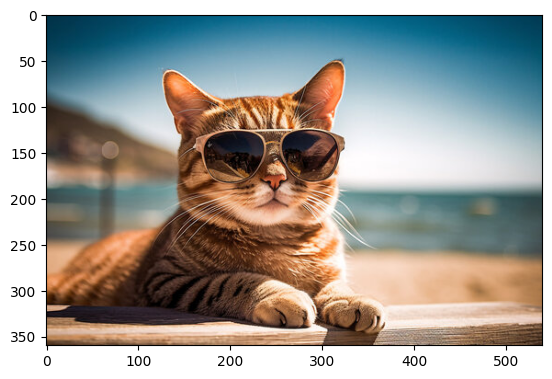

In [2]:
img = plt.imread('cat.jpg')

plt.imshow(img)
height, width = img.shape[:2]

In [3]:
@cuda.jit
def grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
  dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

In [4]:
threshold = 128
blockSize = (16, 16)

gridSize = (
    (width + blockSize[0] - 1) // blockSize[0],
    (height + blockSize[1] - 1) // blockSize[1]
)

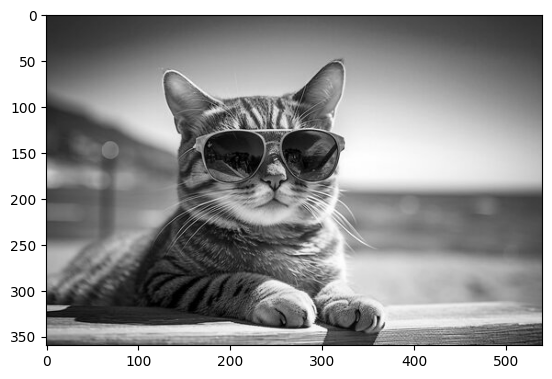

In [5]:
devSrc = cuda.to_device(img)
devDst = cuda.device_array(img.shape, np.uint8)
grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)

In [6]:
@cuda.jit
def binarize(src, dst, threshold):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)

    if g < threshold:
        b = 0
    else:
        b = 255

    dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = b

In [7]:
devSrc = cuda.to_device(img)
devDst = cuda.device_array(img.shape, np.uint8)

In [8]:
start = time.time()

binarize[gridSize, blockSize](devSrc, devDst, threshold)

cuda.synchronize()

elapsed = time.time() - start

print("GPU Time:", elapsed)

GPU Time: 0.14614415168762207


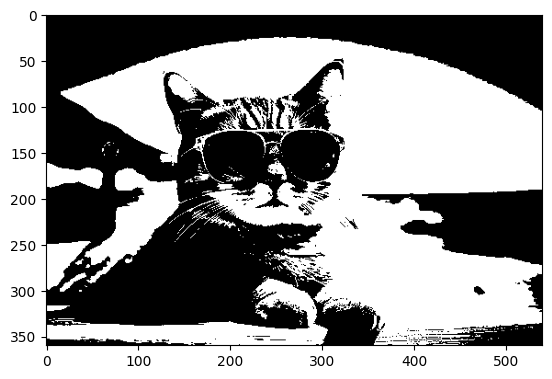

In [9]:
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)

In [95]:
blocks = [(8, 8),(16, 16),(32, 8), (32, 16), (32, 32)]
times_binarize = []

for block in blocks:
  gridSize = (
        (width + blockSize[0] - 1) // blockSize[0],
        (height + blockSize[1] - 1) // blockSize[1])

  devSrc = cuda.to_device(img)
  devDst = cuda.device_array(img.shape, np.uint8)

  start = time.time()
  binarize[gridSize, blockSize](devSrc, devDst, threshold)
  cuda.synchronize()
  elapsed = time.time() - start
  times_binarize.append(elapsed)
  print(blockSize, elapsed)

(16, 16) 0.0004832744598388672
(16, 16) 0.00028252601623535156
(16, 16) 0.000255584716796875
(16, 16) 0.00023603439331054688
(16, 16) 0.0002741813659667969


## 6b: Brightness control


In [10]:
@cuda.jit
def brightness(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    value = 100
    for i in range(3):
      new = src[y, x, i] + value

      if new > 255:
          new = 255

      if new < 0:
          new = 0

      dst[y, x, i] = new

In [11]:
blockSize = (16, 16)

gridSize = (
    (width + blockSize[0] - 1) // blockSize[0],
    (height + blockSize[1] - 1) // blockSize[1]
)
devSrc = cuda.to_device(img)
devDst = cuda.device_array(img.shape, np.uint8)
start = time.time()

brightness[gridSize, blockSize](devSrc, devDst)

cuda.synchronize()

elapsed = time.time() - start

print("GPU Time:", elapsed)

GPU Time: 0.09499096870422363


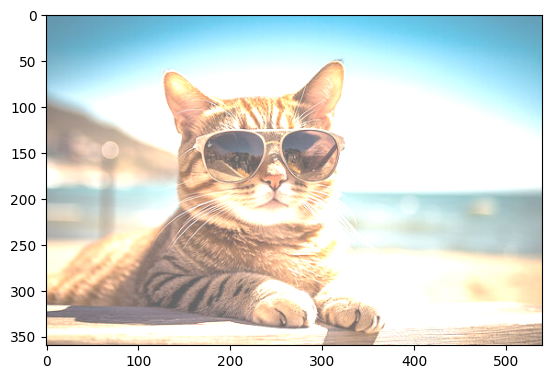

In [12]:
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)

In [96]:
times_brightness = []

for blockSize in blocks:

    gridSize = (
        (width + blockSize[0] - 1) // blockSize[0],
        (height + blockSize[1] - 1) // blockSize[1])

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array(img.shape, np.uint8)

    start = time.time()
    brightness[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()
    elapsed = time.time() - start
    times_brightness.append(elapsed)

    print(blockSize, elapsed)

(8, 8) 0.0011456012725830078
(16, 16) 0.00025463104248046875
(32, 8) 0.0002334117889404297
(32, 16) 0.00024127960205078125
(32, 32) 0.0001785755157470703


##6c: Blending images

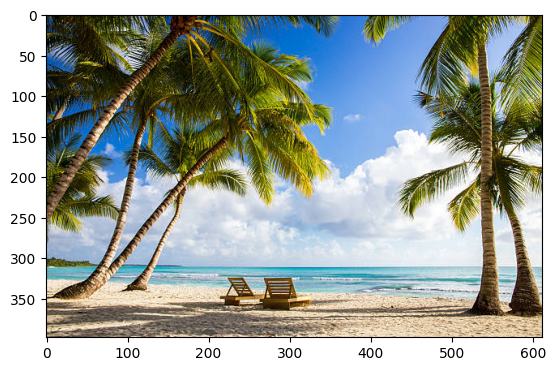

In [86]:
beach = plt.imread('beach.jpg')
plt.imshow(beach)

In [88]:
print(img.shape)
print(beach.shape)

(360, 540, 3)
(398, 612, 3)


In [89]:
from PIL import Image

beach = np.array(Image.open('beach.jpg').resize((width, height)))

In [76]:
c = 0.5
blockSize = (16, 16)

gridSize = (
    (width + blockSize[0] - 1) // blockSize[0],
    (height + blockSize[1] - 1) // blockSize[1])

In [90]:
@cuda.jit
def combine(src1, src2, dst, c):

  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  for i in range(3):
      dst[tidy, tidx, i] = c * src1[tidy, tidx, i] + (1 - c) * src2[tidy, tidx, i]

In [91]:
devImg = cuda.to_device(img)
devBeach = cuda.to_device(beach)
devDst = cuda.device_array(img.shape, np.uint8)

In [92]:
start = time.time()
combine[gridSize, blockSize](devImg, devBeach, devDst, c)
cuda.synchronize()
elapsed = time.time() - start
print("Time:", elapsed)

Time: 0.11445331573486328


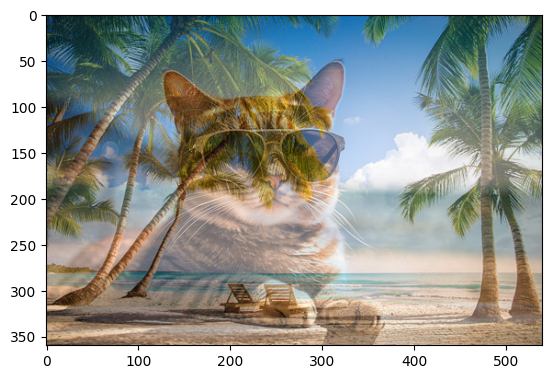

In [93]:
hostDst = devDst.copy_to_host()

plt.imshow(hostDst)

In [97]:
times_combine = []

for blockSize in blocks:

    gridSize = (
        (width + blockSize[0] - 1) // blockSize[0],
        (height + blockSize[1] - 1) // blockSize[1])

    devImg = cuda.to_device(img)
    devDog = cuda.to_device(beach)
    devDst = cuda.device_array(img.shape, np.uint8)

    start = time.time()
    combine[gridSize, blockSize](devImg, devBeach, devDst, 0.5)
    cuda.synchronize()
    elapsed = time.time() - start
    times_combine.append(elapsed)
    print(blockSize, elapsed)

(8, 8) 0.0005040168762207031
(16, 16) 0.0002696514129638672
(32, 8) 0.0003132820129394531
(32, 16) 0.0003268718719482422
(32, 32) 0.00027823448181152344
